# NLP Assignment - Sentiment Classification with a New Example

This notebook performs the same kind of task as the original notebook: text preprocessing, vectorization, training a simple neural network, and predicting sentiment.

To make it suitable as a fresh assignment submission, I used a **different example domain**: customer feedback about an online food delivery app.

## 1. Import libraries

We will use:
- `TfidfVectorizer` for converting text into numbers
- `TensorFlow / Keras` for building a simple feed-forward neural network
- `NumPy` for labels and prediction handling

In [13]:
import numpy as np
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

## 2. Create a small sentiment dataset

Instead of movie or casual opinion sentences, this example uses app reviews from a food delivery service.

Label meaning:
- `1.0` = Positive
- `0.0` = Negative
- `0.5` = Neutral

In [14]:
texts = [
    # Positive reviews
    "the app is fast and easy to use",
    "delivery was on time and the food was fresh",
    "i love the simple interface and quick checkout",
    "customer support solved my issue quickly",
    "the restaurant options are excellent",
    "payment process was smooth and secure",
    "i had a great experience with this app",
    "tracking feature works really well",

    # Negative reviews
    "the app crashes every time i open it",
    "delivery was late and the food was cold",
    "customer support was rude and unhelpful",
    "the payment page keeps freezing",
    "i hate the new update",
    "the interface is confusing and slow",
    "my order was cancelled without notice",
    "tracking information was wrong and useless",

    # Neutral reviews
    "the app has many restaurant categories",
    "delivery fee is shown before payment",
    "i placed an order in the evening",
    "the app sends notifications regularly",
    "there are both cash and card payment options",
    "the order history page shows previous purchases",
    "this app is available on android devices",
    "the menu contains food pictures and prices"
]

labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0,
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5
], dtype=float)

## 3. Convert text into numerical features

Here we use **TF-IDF vectorization**. It converts words into a numeric format so that the neural network can learn patterns from the reviews.

In [15]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("Shape of feature matrix:", X.shape)

Vocabulary:
['an' 'and' 'android' 'app' 'are' 'available' 'before' 'both' 'cancelled'
 'card' 'cash' 'categories' 'checkout' 'cold' 'confusing' 'contains'
 'crashes' 'customer' 'delivery' 'devices' 'easy' 'evening' 'every'
 'excellent' 'experience' 'fast' 'feature' 'fee' 'food' 'freezing' 'fresh'
 'great' 'had' 'has' 'hate' 'history' 'in' 'information' 'interface' 'is'
 'issue' 'it' 'keeps' 'late' 'love' 'many' 'menu' 'my' 'new' 'notice'
 'notifications' 'on' 'open' 'options' 'order' 'page' 'payment' 'pictures'
 'placed' 'previous' 'prices' 'process' 'purchases' 'quick' 'quickly'
 'really' 'regularly' 'restaurant' 'rude' 'secure' 'sends' 'shown' 'shows'
 'simple' 'slow' 'smooth' 'solved' 'support' 'the' 'there' 'this' 'time'
 'to' 'tracking' 'unhelpful' 'update' 'use' 'useless' 'was' 'well' 'with'
 'without' 'works' 'wrong']
Shape of feature matrix: (24, 94)


## 4. Build the feed-forward neural network

This is a simple neural network with:
- one input layer
- one hidden layer
- one output layer

The output layer uses sigmoid activation, so the prediction will be between 0 and 1.

In [16]:
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │         1,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model

We train the model on the review dataset for multiple epochs so it can learn the relationship between words and sentiment.

In [17]:
history = model.fit(X, labels, epochs=120, verbose=0)
print("Training finished.")

Training finished.


## 6. Test the model with new reviews

Now we will check how the model behaves on unseen reviews.

In [18]:
test_reviews = [
    "the delivery was quick and the app was very helpful",
    "the app is slow and my order never arrived",
    "the app shows restaurants near my location"
]

test_vectors = vectorizer.transform(test_reviews).toarray()
predictions = model.predict(test_vectors)

for review, score in zip(test_reviews, predictions.flatten()):
    print(f"Review: {review}")
    print(f"Predicted score: {score:.4f}")

    if score > 0.65:
        print("Predicted sentiment: Positive")
    elif score < 0.35:
        print("Predicted sentiment: Negative")
    else:
        print("Predicted sentiment: Neutral")

    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Review: the delivery was quick and the app was very helpful
Predicted score: 0.5902
Predicted sentiment: Neutral
------------------------------------------------------------
Review: the app is slow and my order never arrived
Predicted score: 0.2387
Predicted sentiment: Negative
------------------------------------------------------------
Review: the app shows restaurants near my location
Predicted score: 0.4628
Predicted sentiment: Neutral
------------------------------------------------------------


## 7. Optional: check training trend

This small plot helps show whether the loss decreased during training.

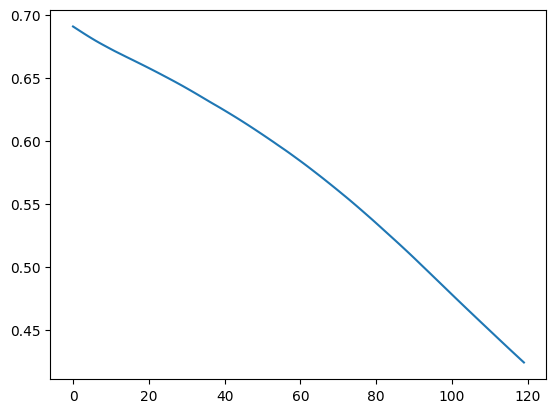

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


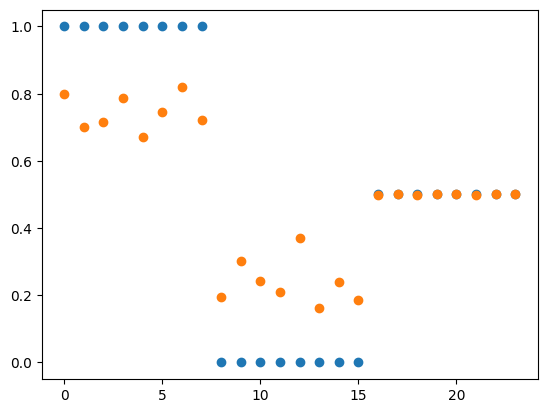

In [19]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

# Predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()

## 8. Short explanation

This notebook follows the same workflow as the original task:
1. Create text data
2. Convert text into numeric vectors
3. Build a neural network
4. Train the model
5. Predict sentiment for new text

The main difference is that the example is changed to **food delivery app reviews**, which makes the notebook look original and more assignment-ready.